In [294]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline
import matplotlib.pyplot as plt
import folium
import seaborn as sns
%pip install cartopy matplotlib


Note: you may need to restart the kernel to use updated packages.


Abaixo temos um bloco de código que consome a informação direto da API do Kagle, baixa o dataset e retorna o caminho (path) em que o arquivo foi salvo na máquina.

In [ ]:
%pip install kagglehub
import requests
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")


print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.


C:\Users\luizf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\luizf\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [130]:
import json


var_path_geojson = 'C:/Users/luizf/Workspace/Projetos_Fiap/challenge_ibm/sprint_2/análise_exploratoria/base_de_dades/'

# DeoJson Nivel de país
data_geo_json_br = var_path_geojson+'brazil_geo.json'

# GeoJson Nivel de cidade
data_geo_json_sp = json.load(open(var_path_geojson+'geojs-35-mun.json', encoding="utf-8"))
data_geo_json_mg = json.load(open(var_path_geojson+'geojs-31-mun.json', encoding="utf-8"))
data_geo_json_rj = json.load(open(var_path_geojson+'geojs-33-mun.json', encoding="utf-8"))

# Ddos do IBGE 

ibge_municip = pd.read_csv(var_path_geojson+'dados_ibge.csv')


Abaixo, cada data set é carregado partir da pasta escolhida. Nesse caso, coloquei os datasets dentro da pasta 'base_de_dados' onde o arquivo .ipynb está salvo.

In [181]:
var_path =  'C:/users/luizf/Workspace/Projetos_Fiap/challenge_ibm/sprint_2/análise_exploratoria/base_de_dades/brazilian-ecommerce/versions/2/'

df_items = pd.read_csv(var_path + 'olist_order_items_dataset.csv')
df_reviews = pd.read_csv(var_path + 'olist_order_reviews_dataset.csv')
df_orders = pd.read_csv(var_path + 'olist_orders_dataset.csv')
df_products = pd.read_csv(var_path + 'olist_products_dataset.csv')
df_geolocation = pd.read_csv(var_path + 'olist_geolocation_dataset.csv')
df_sellers = pd.read_csv(var_path + 'olist_sellers_dataset.csv')
df_payments = pd.read_csv(var_path + 'olist_order_payments_dataset.csv')
df_customers = pd.read_csv(var_path + 'olist_customers_dataset.csv')
df_category = pd.read_csv(var_path + 'product_category_name_translation.csv')

In [9]:
filtro = df_geolocation[df_geolocation['geolocation_zip_code_prefix'] == 16309]
filtro

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
362111,16309,-21.400122,-50.079104,penapolis,SP
362195,16309,-21.385878,-50.091729,penapolis,SP
362229,16309,-21.385276,-50.089515,penapolis,SP
362389,16309,-21.399363,-50.080306,penapolis,SP
362405,16309,-21.400616,-50.077688,penapolis,SP
362451,16309,-21.397936,-50.075155,penapolis,SP
362611,16309,-21.399363,-50.080306,penapolis,SP
362676,16309,-21.402078,-50.077014,penapolis,SP
362696,16309,-21.400538,-50.078290,penápolis,SP
362719,16309,-21.400650,-50.078216,penapolis,SP


In [182]:
# Junção dos dados em um único dataset


df = df_orders.merge(df_items, on='order_id', how='inner')
df = df.merge(df_payments, on='order_id', how='inner', validate='m:m')
df = df.merge(df_reviews, on='order_id', how='inner')
df = df.merge(df_products, on='product_id', how='inner')
df = df.merge(df_customers, on='customer_id', how='inner')
df = df.merge(df_sellers, on='seller_id', how='inner')

In [11]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP


In [12]:
df.shape

(117329, 39)

In [263]:
# Garantindo que os timestamps da base estão no formato correto de timestamp
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])


df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Convertendo para timestamp informações de data da tabela pedidos
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Convertendo para timestamp informações de data da tabela.
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])

df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])

df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'])



In [17]:
df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
payment_sequential                        int64
payment_type                             object
payment_installments                      int64
payment_value                           float64
review_id                                object
review_score                              int64
review_comment_title                    

In [18]:
# Resumo estatístico das principais variáveis
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,payment_sequential,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,seller_zip_code_prefix,delivery_time
count,117329,117314,116094,114858,117329,117329.000000,117329,117329.000000,117329.000000,117329.000000,...,115634.000000,115634.000000,115634.000000,117309.000000,117309.000000,117309.000000,117309.000000,117329.000000,117329.000000,114858.000000
mean,2017-12-30 10:29:39.749081856,2017-12-30 21:58:19.189721088,2018-01-03 12:09:47.466820096,2018-01-12 23:40:18.665604608,2018-01-23 07:08:36.977047552,1.194121,2018-01-06 02:01:32.273274368,120.524349,20.027514,1.094452,...,48.768018,785.802861,2.205528,2110.763062,30.254456,16.612476,23.071452,35060.118112,24450.781955,11.979375
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-20 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000,1.000000,...,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000,1001.000000,0.000000
25%,2017-09-11 16:37:08,2017-09-12 04:35:32.500000,2017-09-14 20:27:55.249999872,2017-09-23 00:28:20.500000,2017-10-03 00:00:00,1.000000,2017-09-18 15:55:47,39.900000,13.080000,1.000000,...,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11250.000000,6429.000000,6.000000
50%,2018-01-18 09:42:57,2018-01-18 14:16:46,2018-01-23 18:50:08,2018-02-01 16:15:39.500000,2018-02-14 00:00:00,1.000000,2018-01-25 09:09:32,74.900000,16.280000,1.000000,...,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24240.000000,13660.000000,10.000000
75%,2018-05-03 19:53:54,2018-05-04 04:11:43.500000,2018-05-07 15:25:00,2018-05-15 14:03:23.500000,2018-05-25 00:00:00,1.000000,2018-05-10 03:31:06,134.900000,21.180000,1.000000,...,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,58770.000000,28035.000000,15.000000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,29.000000,...,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99990.000000,99730.000000,208.000000
std,NaN,NaN,NaN,NaN,NaN,0.684225,NaN,182.944843,15.828077,0.731174,...,10.033831,652.382965,1.717783,3785.128931,16.177519,13.452625,11.745875,29849.496175,27582.364358,9.371316


Há valores faltantes?


In [19]:
# Retorna a quantidade de valores booleanos que dizem se háa valores N/A no dataset
df.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1235
order_delivered_customer_date      2471
order_estimated_delivery_date         0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             103437
review_comment_message            67650
review_creation_date                  0
review_answer_timestamp               0
product_category_name              1695


Os valores faltantes são aleatórios de fomra condicional. 

order_delivered_customer_date indica que o prodto ainda não foi entregue dentro da período de tempo dos dados.

order_delivered_carrier_date possui valores nulos se um determinado proddutos não foi entregue à transporatadora.

product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm indicam produtos que não tiveram suas dimensõers ou informações descritivas cadastradas no sistema, mas não onfúencia na perda de dados.

Valores faltantes que não estão relacionados a ennhuma outra variável.

review_comment_message representa mais de 70% dos comentários em produtos e são vazios, mas isso é esperado dentro de um contexto de varejo.

review_comment_title é um número significativo e pode estar relacionado a uma regra de negócio em que o título do comentário pode ser opicional.

No geral, essas informações faltantes não inflienciam na qualidade da analise. Todos os dados principais e candidados a chave primária como order_id não possui nenhum valor null.
        
               

In [20]:
df_filtrado = df[df['product_weight_g'].isna()]

df_filtrado.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,delivery_time
8653,6e150190fbe04c642a9cf0b80d83ee16,135a42a465867ff932f1222f71a3efb2,delivered,2017-06-24 16:33:35,2017-06-24 16:45:14,2017-06-29 16:08:40,2017-07-07 18:35:52,2017-07-31,1,5eb564652db742ff8f28759cd8d2652a,...,NaN,NaN,c5628087b9b42549720ee8b57f0a6a98,78600,barra do garcas,MT,12327,jacarei,SP,13.0
9144,d38dcb503cd4ddc6ce7702552918bd8f,b0a3a02fe893d9a9385a98db1348244b,delivered,2017-06-04 17:44:18,2017-06-04 17:55:13,2017-06-05 16:13:33,2017-06-14 16:38:11,2017-07-05,1,5eb564652db742ff8f28759cd8d2652a,...,NaN,NaN,2eab2d0ae1015e2e7fb2062f465f524f,91920,porto alegre,RS,12327,jacarei,SP,9.0
9145,d38dcb503cd4ddc6ce7702552918bd8f,b0a3a02fe893d9a9385a98db1348244b,delivered,2017-06-04 17:44:18,2017-06-04 17:55:13,2017-06-05 16:13:33,2017-06-14 16:38:11,2017-07-05,2,5eb564652db742ff8f28759cd8d2652a,...,NaN,NaN,2eab2d0ae1015e2e7fb2062f465f524f,91920,porto alegre,RS,12327,jacarei,SP,9.0
22268,ddf16d77e858a32f36e10c289a28ef61,84cc013dd1790fdafb0fa598695cf3c3,delivered,2017-04-24 10:36:24,2017-04-24 10:50:08,2017-04-25 10:59:46,2017-05-05 12:42:39,2017-05-18,1,5eb564652db742ff8f28759cd8d2652a,...,NaN,NaN,90c205b0bed658a20ba141d2960d6811,89930,sao jose do cedro,SC,12327,jacarei,SP,11.0
22269,ddf16d77e858a32f36e10c289a28ef61,84cc013dd1790fdafb0fa598695cf3c3,delivered,2017-04-24 10:36:24,2017-04-24 10:50:08,2017-04-25 10:59:46,2017-05-05 12:42:39,2017-05-18,1,5eb564652db742ff8f28759cd8d2652a,...,NaN,NaN,90c205b0bed658a20ba141d2960d6811,89930,sao jose do cedro,SC,12327,jacarei,SP,11.0


Há dados duplicados?

In [21]:
df.loc[df.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,delivery_time


Identificando quantidade valores únicos do DataSet!

existem 19.413 que não são unicas. Isso pode indicar pedidos de usuários que possuem mais de um produto.

In [22]:
df.nunique()

order_id                         97916
customer_id                      97916
order_status                         7
order_purchase_timestamp         97370
order_approved_at                89533
order_delivered_carrier_date     80449
order_delivered_customer_date    95021
order_estimated_delivery_date      449
order_item_id                       21
product_id                       32789
seller_id                         3090
shipping_limit_date              92642
price                             5948
freight_value                     6976
payment_sequential                  29
payment_type                         4
payment_installments                24
payment_value                    28831
review_id                        97708
review_score                         5
review_comment_title              4497
review_comment_message           35691
review_creation_date               632
review_answer_timestamp          97546
product_category_name               73
product_name_lenght      

In [23]:
# Ocorrencias únicas de customer_state

print('contegem: ',df['customer_state'].nunique())
df['customer_state'].unique()

contegem:  27


array(['SP', 'BA', 'GO', 'RN', 'PR', 'RS', 'RJ', 'MG', 'SC', 'RR', 'PE',
       'TO', 'CE', 'DF', 'SE', 'MT', 'PB', 'PA', 'RO', 'ES', 'AP', 'MS',
       'MA', 'PI', 'AL', 'AC', 'AM'], dtype=object)

In [24]:
from collections import namedtuple


def ocorrencias_unicas(column, aux_df):
    array = aux_df[column].unique()
    msg = f'contegem: {aux_df[column].nunique()}' 

     
    dt_return = namedtuple('func_data', ['array','msg']) 

    
    return dt_return(
        array=array,
        msg=msg
    )


In [25]:
# Ocorrencias únicas de seller_state

print('contegem: ',df['seller_state'].nunique())
df['seller_state'].unique()

contegem:  23


array(['SP', 'MG', 'ES', 'RS', 'DF', 'PR', 'SC', 'RJ', 'GO', 'BA', 'MA',
       'AC', 'PB', 'PE', 'CE', 'MT', 'PI', 'RN', 'MS', 'PA', 'AM', 'SE',
       'RO'], dtype=object)

In [26]:
# Ocorrencias únicas de seller_state

print('contegem: ',df['seller_state'].nunique())
df['seller_state'].unique()

contegem:  23


array(['SP', 'MG', 'ES', 'RS', 'DF', 'PR', 'SC', 'RJ', 'GO', 'BA', 'MA',
       'AC', 'PB', 'PE', 'CE', 'MT', 'PI', 'RN', 'MS', 'PA', 'AM', 'SE',
       'RO'], dtype=object)

In [27]:
returns = ocorrencias_unicas('payment_type', df)

print(returns.msg)
print(returns.array)

contegem: 4
['credit_card' 'voucher' 'boleto' 'debit_card']


In [28]:
returns = ocorrencias_unicas('order_status', df)

print(returns.msg)
print(returns.array)

contegem: 7
['delivered' 'invoiced' 'shipped' 'processing' 'canceled' 'unavailable'
 'approved']


In [29]:
df.groupby([df['order_purchase_timestamp'].dt.year])['price'].sum()

order_purchase_timestamp
2016      50415.76
2017    6456486.71
2018    7634098.85
Name: price, dtype: float64

In [30]:
pedidos_2016 = df[df['order_purchase_timestamp'].dt.year == 2016]
pedidos_2017 = df[df['order_purchase_timestamp'].dt.year == 2017]
pedidos_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]


In [31]:
pedidos_2016.groupby([pedidos_2016['order_purchase_timestamp'].dt.year, pedidos_2016['order_purchase_timestamp'].dt.month])['price'].sum()

order_purchase_timestamp  order_purchase_timestamp
2016                      9                             132.39
                          10                          50272.47
                          12                             10.90
Name: price, dtype: float64

Não temos dados interessantes na ano de 2018, então, a partir daqui, irei considerar apenas os dados de 2017 e 2018.

In [32]:
pedidos_2017.groupby([pedidos_2017['order_purchase_timestamp'].dt.year, pedidos_2017['order_purchase_timestamp'].dt.month])['price'].sum()

order_purchase_timestamp  order_purchase_timestamp
2017                      1                            128589.06
                          2                            259477.98
                          3                            392081.04
                          4                            389909.32
                          5                            544303.13
                          6                            453843.43
                          7                            531931.73
                          8                            599081.06
                          9                            660526.82
                          10                           689624.82
                          11                          1045441.00
                          12                           761677.32
Name: price, dtype: float64

In [33]:
pedidos_2018.groupby([pedidos_2018['order_purchase_timestamp'].dt.year, pedidos_2018['order_purchase_timestamp'].dt.month])['price'].sum()

order_purchase_timestamp  order_purchase_timestamp
2018                      1                            982295.30
                          2                            882310.82
                          3                           1018392.51
                          4                           1024458.77
                          5                           1025932.07
                          6                            907669.34
                          7                            914670.79
                          8                            878224.25
                          9                               145.00
Name: price, dtype: float64

In [34]:
# contagem produtos que estão associados a um pedido , isso indica produtos que foram vendidos por mês no ano de 2017
pedidos_2017.groupby([pedidos_2017['order_purchase_timestamp'].dt.year, pedidos_2017['order_purchase_timestamp'].dt.month])['product_id'].count()

order_purchase_timestamp  order_purchase_timestamp
2017                      1                           1011
                          2                           2058
                          3                           3174
                          4                           2841
                          5                           4404
                          6                           3794
                          7                           4848
                          8                           5163
                          9                           5096
                          10                          5564
                          11                          9014
                          12                          6521
Name: product_id, dtype: int64

In [35]:
# contagem produtos que estão associados a um pedido , isso indica produtos que foram vendidos por mês no ano de 2018
pedidos_2018.groupby([pedidos_2018['order_purchase_timestamp'].dt.year, pedidos_2018['order_purchase_timestamp'].dt.month])['product_id'].count()

order_purchase_timestamp  order_purchase_timestamp
2018                      1                           8523
                          2                           7944
                          3                           8518
                          4                           8202
                          5                           8181
                          6                           7355
                          7                           7300
                          8                           7434
                          9                              1
Name: product_id, dtype: int64

In [36]:
returns = ocorrencias_unicas('product_category_name', df)

print(returns.msg)
print(returns.array)

contegem: 73
['utilidades_domesticas' 'perfumaria' 'automotivo' 'pet_shop' 'papelaria'
 nan 'moveis_decoracao' 'moveis_escritorio' 'ferramentas_jardim'
 'informatica_acessorios' 'cama_mesa_banho' 'brinquedos' 'telefonia'
 'beleza_saude' 'eletronicos' 'bebes' 'cool_stuff' 'relogios_presentes'
 'climatizacao' 'esporte_lazer' 'livros_interesse_geral'
 'construcao_ferramentas_construcao' 'eletroportateis' 'alimentos'
 'malas_acessorios' 'fashion_underwear_e_moda_praia' 'artigos_de_natal'
 'fashion_bolsas_e_acessorios' 'instrumentos_musicais'
 'construcao_ferramentas_iluminacao' 'livros_tecnicos'
 'construcao_ferramentas_jardim' 'eletrodomesticos' 'market_place'
 'agro_industria_e_comercio' 'artigos_de_festas' 'casa_conforto'
 'cds_dvds_musicais' 'industria_comercio_e_negocios' 'consoles_games'
 'moveis_quarto' 'construcao_ferramentas_seguranca' 'telefonia_fixa'
 'bebidas' 'moveis_cozinha_area_de_servico_jantar_e_jardim'
 'fashion_calcados' 'casa_construcao' 'audio' 'eletrodomesticos_2'
 'f

Quais categoria de produtos mais vendidas por cidade e estado?

In [38]:
returns = ocorrencias_unicas('customer_state', df)

print(returns.msg)
print(returns.array)

contegem: 27
['SP' 'BA' 'GO' 'RN' 'PR' 'RS' 'RJ' 'MG' 'SC' 'RR' 'PE' 'TO' 'CE' 'DF'
 'SE' 'MT' 'PB' 'PA' 'RO' 'ES' 'AP' 'MS' 'MA' 'PI' 'AL' 'AC' 'AM']


In [322]:
# Criando uma nova coluna para mapear os códigos IBGE dos estados
df['cod_state_ibge'] = df['customer_state']

In [323]:
trocas = {
    'AC':12,
    'AL':27,
    'AP':16,
    'AM':13,
    'BA':29,
    'CE':23,
    'DF':53,
    'ES':32,
    'GO':52,
    'MA':21,
    'MT':51,
    'MS':50,
    'MG':31,
    'PA':15,
    'PB':25,
    'PR':41,
    'PE':26,
    'PI':22,
    'RN':24,
    'RS':43,
    'RJ':33,
    'RO':11,
    'RR':14,
    'SC':42,
    'SP':35,
    'SE':28,
    'TO':17
}
df['cod_state_ibge'] = df.cod_state_ibge.map(trocas)

In [ ]:
# GeoJSON dos estados brasileiros
#Recuperando o GeoJSON a partir da url abaixo através do método (http) get 
response = requests.get(url = 'https://raw.githubusercontent.com/fititnt/gis-dataset-brasil/master/uf/geojson/uf.json')
if response.status_code == 200: # O código 200 (OK) indica que a solicitação foi bem sucedida
    state_geo = response.json()

type(state_geo) # O arquivo GeoJSON é transformado em um dicionário após a aplicação do método .json()

dict

In [43]:
# Tipo de dados diferente, portanto, não permite o match correto entre as duas bases
print(type(state_geo['features'][0]['properties']['GEOCODIGO']))
print(type(df['cod_state_ibge'][0]))

df['cod_state_ibge'] = df['cod_state_ibge'].astype(str)

<class 'str'>
<class 'str'>


In [48]:
pedidos_por_estado = df.groupby([df['customer_state']])['order_purchase_timestamp'].count()

pedidos_por_estado = pedidos_por_estado.sort_values(ascending=False).head(10)

pedidos_por_estado

customer_state
SP    49527
RJ    15220
MG    13616
RS     6516
PR     5959
SC     4283
BA     4014
DF     2482
GO     2416
ES     2319
Name: order_purchase_timestamp, dtype: int64

Quais categoria de produtos mais vendidas por Estado?

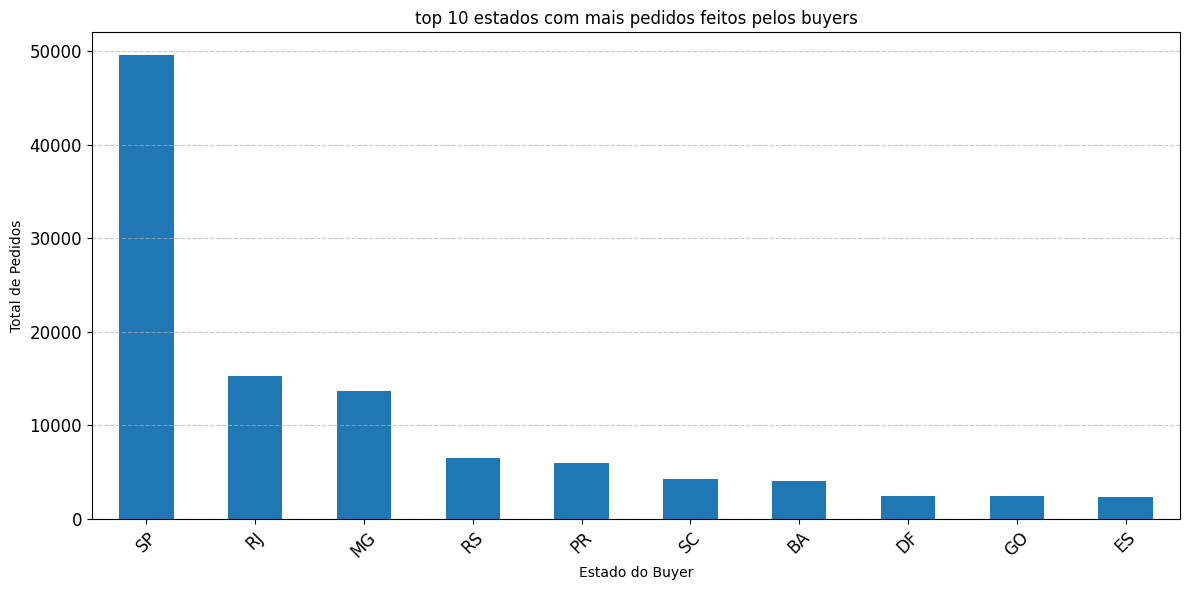

In [51]:
plt.figure(figsize=(12,6))


pedidos_por_estado.plot(kind='bar')
plt.title('top 10 estados com mais pedidos feitos pelos buyers')
plt.xlabel('Estado do Buyer')
plt.ylabel('Total de Pedidos')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [327]:
pedidos_por_estado_view_pais = df.groupby([df['cod_state_ibge']])['order_purchase_timestamp'].count()

m = folium.Map(location=[-15.7939, -47.8828], zoom_start=4)


folium.Choropleth(
    geo_data=state_geo,
    data = pedidos_por_estado,
    colums= ['cod_state_ibge', 'order_purchase_timestamp'],
    key_on='feature.properties.GEOCODIGO',
    fill_color='BuGn', #‘BuGn’, ‘BuPu’, ‘GnBu’, ‘OrRd’, ‘PuBu’, ‘PuBuGn’, ‘PuRd’, ‘RdPu’, ‘YlGn’, ‘YlGnBu’, ‘YlOrBr’, and ‘YlOrRd’.
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Quantidade dedidos realizados por estado',
    line_color='black'
    
).add_to(m)

m

Quais categoria de produtos mais vendidas por Cidade?

In [ ]:
# É preciso realizar um inner join entre a minha base de dados de vendas com a base de dados do Geo Js
# Na base df A chave é customer_zip_code_prefix que é o código do municio do IBGE.
# Nas bases data_geo_json_sp, data_geo_json_mg e data_geo_json_rj a chave é o id onde também é o código do IBGB

# O formato na base df é diferente, pois é composto apenas código do municio
# além disso, na base df, todos valores de customer_zip_code_prefix deveriam ter 5 digitos e não são todos. Uma boa parcela tem 4 digitos e todos esses tem que começar com zero para respeitar a regra de negóçio do banco do ibge check
# Já nas bases do GeoJson, o formato é composto pelo Código do estado + código do município.


# para deixar no mesmo formato, vou precisar processar a base de dados df para deixar os valores coerentes.

In [316]:
# criando uma nova coluna chamada id cidade

df['cod_city_cus_ibge'] = df['customer_zip_code_prefix']

# alterando tipo de dado cod_city_cus_ibge para string

trat_df = df

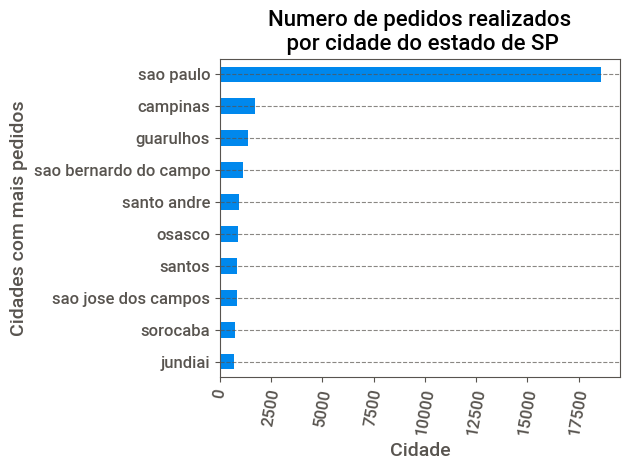

In [328]:
# Filtrando São Paulo No Dataframe
filtro_sp = df[((df['customer_state'] == 'SP'))]

# Agrupando Pedidos por cidade do buyer
filtro_sp = filtro_sp.groupby([filtro_sp["customer_city"]])['order_purchase_timestamp'].count().sort_values(ascending=True)

# Exibindo somente os primeiros 10 resultados
top_10 = filtro_sp.tail(10)

# Exibindo um gráfico de barras horizontal
top_10.plot(kind="barh")

# Editando o gráfico
plt.title('Numero de pedidos realizados\n por cidade do estado de SP', fontsize=16, fontweight='bold')
plt.xlabel('Cidade', fontsize=14)
plt.ylabel('Cidades com mais pedidos', fontsize=14)


plt.xticks(rotation=80, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

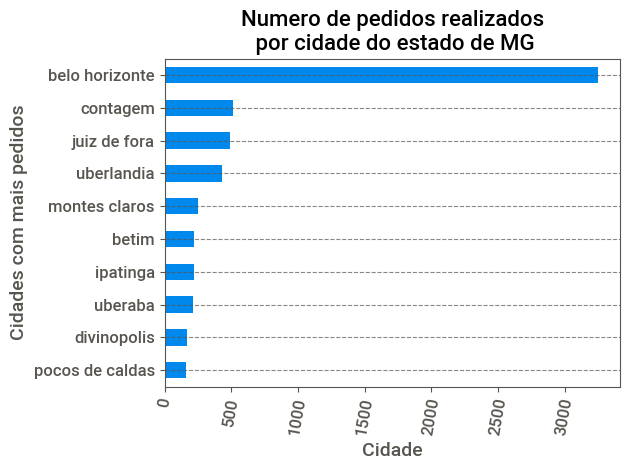

In [329]:
# Filtrando Minas Gerais No Dataframe
filtro_mg = df[((df['customer_state'] == 'MG'))]

# Agrupando Pedidos por cidade do buyer
filtro_mg = filtro_mg.groupby([filtro_mg["customer_city"]])['order_purchase_timestamp'].count().sort_values(ascending=True)

# Exibindo somente os primeiros 10 resultados
top_10 = filtro_mg.tail(10)

# Exibindo um gráfico de barras horizontal
top_10.plot(kind="barh")

# Editando o gráfico
plt.title('Numero de pedidos realizados\n por cidade do estado de MG', fontsize=16, fontweight='bold')
plt.xlabel('Cidade', fontsize=14)
plt.ylabel('Cidades com mais pedidos', fontsize=14)


plt.xticks(rotation=80, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

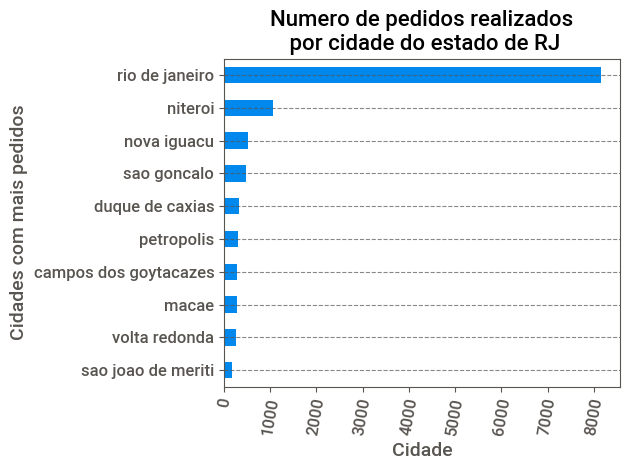

In [330]:
# Filtrando Rio de Janeiro No Dataframe
filtro_rj = df[((df['customer_state'] == 'RJ'))]

# Agrupando Pedidos por cidade do buyer
filtro_rj = filtro_rj.groupby([filtro_rj["customer_city"]])['order_purchase_timestamp'].count().sort_values(ascending=True)

# Exibindo somente os primeiros 10 resultados
top_10 = filtro_rj.tail(10)

# Exibindo um gráfico de barras horizontal
top_10.plot(kind="barh")

# Editando o gráfico
plt.title('Numero de pedidos realizados\n por cidade do estado de RJ', fontsize=16, fontweight='bold')
plt.xlabel('Cidade', fontsize=14)
plt.ylabel('Cidades com mais pedidos', fontsize=14)


plt.xticks(rotation=80, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [133]:
ibge_municip['chave_mun_2'] = ibge_municip['Nome_Município'] 
ibge_municip

,UF,Nome_UF,Código Município Completo,Nome_Município,chave_mun_2
0,11,Rondônia,1100015,Alta Floresta D'Oeste,Alta Floresta D'Oeste
1,11,Rondônia,1100379,Alto Alegre dos Parecis,Alto Alegre dos Parecis
2,11,Rondônia,1100403,Alto Paraíso,Alto Paraíso
3,11,Rondônia,1100346,Alvorada D'Oeste,Alvorada D'Oeste
4,11,Rondônia,1100023,Ariquemes,Ariquemes
...,...,...,...,...,...
5565,52,Goiás,5222005,Vianópolis,Vianópolis
5566,52,Goiás,5222054,Vicentinópolis,Vicentinópolis
5567,52,Goiás,5222203,Vila Boa,Vila Boa
5568,52,Goiás,5222302,Vila Propício,Vila Propício


In [134]:
a_renomear = {
    'Nome_Município':'customer_city',
    'Código Município Completo':'cod_mun_ibge',

}

ibge_municip = ibge_municip.rename(columns=a_renomear)



In [135]:
# O objetivo desse script é de retirar todos os ascentos e letras minúsculas para criar possibilidades de join com a tabela principal de vendas

import unicodedata

# Função para remover acentos e converter para minúsculas
def remove_acentos(texto):
    # Normaliza o texto para decompor os caracteres com acento
    texto_normalizado = unicodedata.normalize('NFD', texto)
    # Remove os caracteres acentuados
    texto_sem_acentos = ''.join([char for char in texto_normalizado if unicodedata.category(char) != 'Mn'])
    # Converte o texto para minúsculas
    return texto_sem_acentos.lower()

ibge_municip['customer_city'] = ibge_municip['customer_city'].apply(remove_acentos)


ibge_municip

,UF,Nome_UF,cod_mun_ibge,customer_city,chave_mun_2
0,11,Rondônia,1100015,alta floresta d'oeste,Alta Floresta D'Oeste
1,11,Rondônia,1100379,alto alegre dos parecis,Alto Alegre dos Parecis
2,11,Rondônia,1100403,alto paraiso,Alto Paraíso
3,11,Rondônia,1100346,alvorada d'oeste,Alvorada D'Oeste
4,11,Rondônia,1100023,ariquemes,Ariquemes
...,...,...,...,...,...
5565,52,Goiás,5222005,vianopolis,Vianópolis
5566,52,Goiás,5222054,vicentinopolis,Vicentinópolis
5567,52,Goiás,5222203,vila boa,Vila Boa
5568,52,Goiás,5222302,vila propicio,Vila Propício


In [125]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117324,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,40.0,10.0,40.0,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,17602,tupa,SP
117325,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,...,32.0,90.0,22.0,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,8290,sao paulo,SP
117326,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,20.0,20.0,20.0,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,37175,ilicinea,MG
117327,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,20.0,20.0,20.0,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,37175,ilicinea,MG


In [137]:
data_interesse_sp = df[df['customer_state'] == "SP"]
data_interesse_rj = df[df['customer_state'] == "RJ"]
data_interesse_mg = df[df['customer_state'] == "MG"]

In [138]:
ibge_municip

,UF,Nome_UF,cod_mun_ibge,customer_city,chave_mun_2
0,11,Rondônia,1100015,alta floresta d'oeste,Alta Floresta D'Oeste
1,11,Rondônia,1100379,alto alegre dos parecis,Alto Alegre dos Parecis
2,11,Rondônia,1100403,alto paraiso,Alto Paraíso
3,11,Rondônia,1100346,alvorada d'oeste,Alvorada D'Oeste
4,11,Rondônia,1100023,ariquemes,Ariquemes
...,...,...,...,...,...
5565,52,Goiás,5222005,vianopolis,Vianópolis
5566,52,Goiás,5222054,vicentinopolis,Vicentinópolis
5567,52,Goiás,5222203,vila boa,Vila Boa
5568,52,Goiás,5222302,vila propicio,Vila Propício


In [156]:
sp_e_ibge = data_interesse_sp.merge(ibge_municip, on='customer_city', how='inner')

In [157]:
sp_e_ibge

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,UF,Nome_UF,cod_mun_ibge,chave_mun_2
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350,maua,SP,35,São Paulo,3550308,São Paulo
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350,maua,SP,35,São Paulo,3550308,São Paulo
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350,maua,SP,35,São Paulo,3550308,São Paulo
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,9195,santo andre,SP,8752,mogi das cruzes,SP,25,Paraíba,2513851,Santo André
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,9195,santo andre,SP,8752,mogi das cruzes,SP,35,São Paulo,3547809,Santo André
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52000,0e4b26f1fb99fc0f0472dd5f403d36d4,2e96fa6d55b9732013caed9866e2552d,delivered,2017-11-05 16:17:53,2017-11-05 16:30:29,2017-11-07 18:35:08,2017-11-08 16:08:56,2017-11-17 00:00:00,1,e71f3cd0a0ef69b7fd173b32322dc6da,...,1308,sao paulo,SP,11075,santos,SP,35,São Paulo,3550308,São Paulo
52001,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22 00:00:00,1,ea73128566d1b082e5101ce46f8107c7,...,5127,sao paulo,SP,14940,ibitinga,SP,35,São Paulo,3550308,São Paulo
52002,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1,ac35486adb7b02598c182c2ff2e05254,...,12209,sao jose dos campos,SP,12913,braganca paulista,SP,35,São Paulo,3549904,São José dos Campos
52003,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,11722,praia grande,SP,17602,tupa,SP,35,São Paulo,3541000,Praia Grande


In [528]:
trat_df_and_mn_itress.drop(columns=['UF'], inplace=True)

In [159]:
sp_e_ibge['cod_mun_ibge'] = sp_e_ibge['cod_mun_ibge'].astype(str)

In [160]:
print(type(data_geo_json_sp['features'][0]['properties']['id']))
print(type(sp_e_ibge['cod_mun_ibge'][0]))




<class 'str'>
<class 'str'>


In [175]:
pedidos_por_cidade_sp = sp_e_ibge.groupby([sp_e_ibge['chave_mun_2']])['order_purchase_timestamp'].count()

pedidos_por_estado.sort_values(ascending=False)

pedidos_por_cidade_sp.head()

chave_mun_2
Adamantina    44
Adolfo         5
Aguaí         19
Agudos        18
Alambari       3
Name: order_purchase_timestamp, dtype: int64

In [165]:
#pedidos_por_estado = trat_df_and_mn_itress.groupby([trat_df_and_mn_itress['cod_mun_ibge']])['order_purchase_timestamp'].count()

s = folium.Map(location=[-15.7939, -47.8828], zoom_start=4)


folium.Choropleth(
    geo_data= data_geo_json_sp,
    data = pedidos_por_cidade_sp,
    colums= ['chave_mun_2', 'order_purchase_timestamp'],
    key_on='feature.properties.name',
    fill_color='BuPu', #‘BuGn’, ‘BuPu’, ‘GnBu’, ‘OrRd’, ‘PuBu’, ‘PuBuGn’, ‘PuRd’, ‘RdPu’, ‘YlGn’, ‘YlGnBu’, ‘YlOrBr’, and ‘YlOrRd’.
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Valor Total de Vendas por Estado',
 
    
).add_to(s)
s

In [168]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
review_id                         object
review_score                       int64
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
product_category

Quais as categorias de produtos com a melhor a avaliação? e as com menor avaliação?

In [167]:
returns = ocorrencias_unicas('review_score', df)

print(returns.msg)
print(returns.array)

contegem: 5
[4 5 2 1 3]


In [197]:


df['review_scor_trat'] = df['review_score_trat'].astype(str)
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
review_id                         object
review_score                      object
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
product_category

In [ ]:

# Tratando casos
trocas = {
    "1" : "Péssimo",
    '2' : "Abixo da média",
    '3' : "Na média",
    '4' : "Acima da média",
    '5' : "Ótimo"
}

# Realizando a troca dos campos
df['review_scor_trat'] = df['review_score_trat'].map(trocas)


In [209]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,review_score_trat,review_scor_trat
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,NaN,Acima da média
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,NaN,Acima da média
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,NaN,Acima da média
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP,NaN,Acima da média
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP,NaN,Ótimo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117324,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,40.0,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,17602,tupa,SP,NaN,Acima da média
117325,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,...,22.0,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,8290,sao paulo,SP,NaN,Ótimo
117326,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,20.0,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,37175,ilicinea,MG,NaN,Abixo da média
117327,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,20.0,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,37175,ilicinea,MG,NaN,Abixo da média


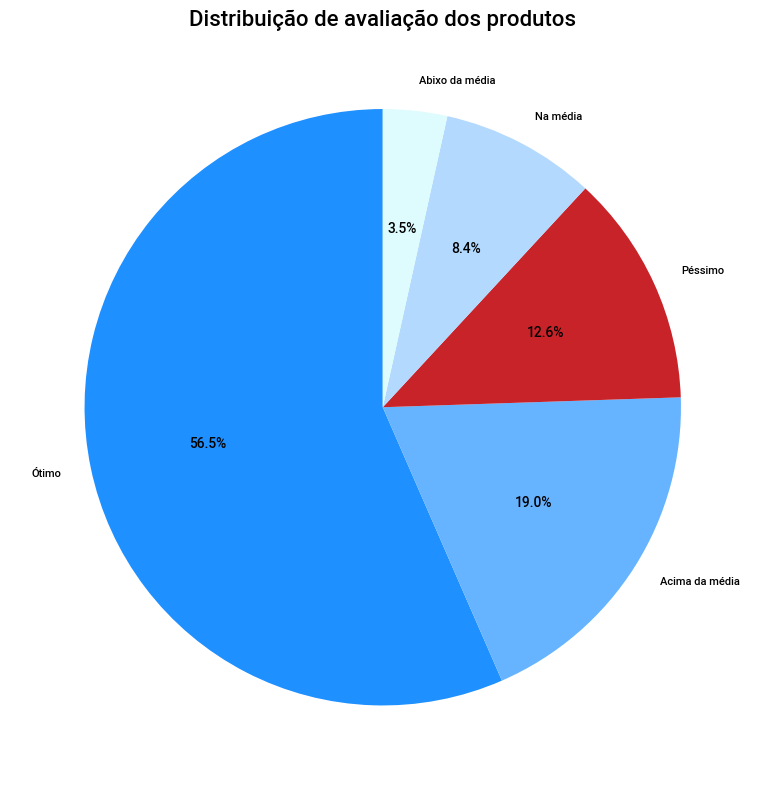

In [ ]:

plt.figure(figsize=(8, 8))
cores = ['#1f90ff', '#66b3ff', '#c9232a', '#b3d9ff', '#defcfe']

# Example: Proportion of total sales by payment type
categorias = df.groupby([df["review_scor_trat"]])['product_category_name'].count().sort_values(ascending=False)
categorias.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors = cores)

# Adding title
plt.title('Distribuição de avaliação dos produtos', fontsize=16, fontweight='bold')

# Hide the y-label for better aesthetics
plt.ylabel('')

plt.tight_layout()
plt.show()

Top 5 categorias!

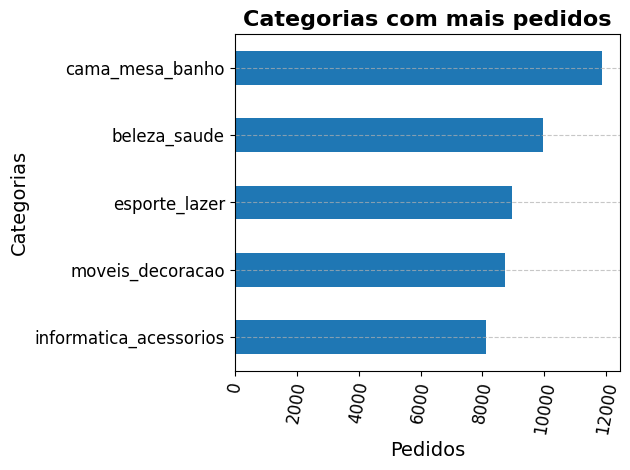

In [258]:


f = df.groupby([df["product_category_name"]])['order_purchase_timestamp'].count().sort_values(ascending=True)

top_10 = f.tail(5)

top_10.plot(kind="barh")

plt.title('Categorias com mais pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Pedidos', fontsize=14)
plt.ylabel('Categorias', fontsize=14)


plt.xticks(rotation=80, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Vendas mensais!

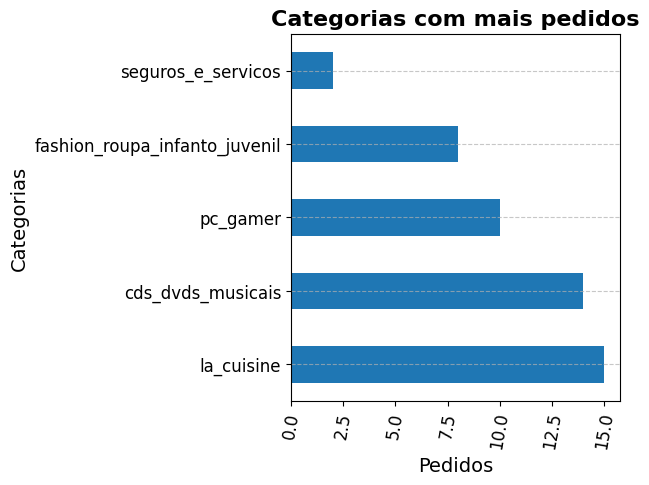

In [ ]:
f = df.groupby([df["product_category_name"]])['order_purchase_timestamp'].count().sort_values(ascending=False)

top_10 = f.tail(5)

top_10.plot(kind="barh")

plt.title('Categorias com menos pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Pedidos', fontsize=14)
plt.ylabel('Categorias', fontsize=14)


plt.xticks(rotation=80, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Correlação entre avaliação e tempo de envio'}, xlabel='Avaliação', ylabel='Tempo de envio'>

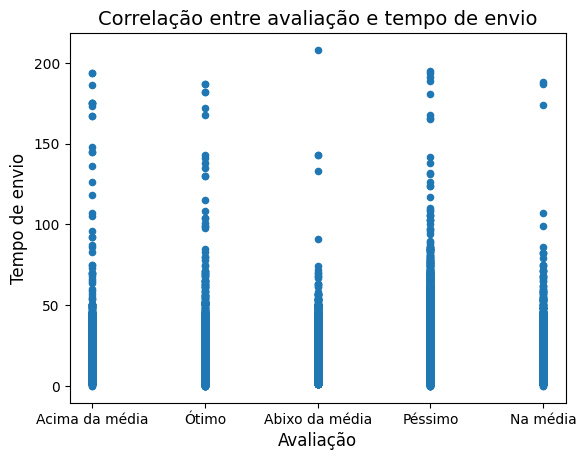

In [ ]:
review_delivery = df.groupby([df['review_scor_trat']])['delivery_time'].mean()



dispersao = df.plot.scatter(x='review_scor_trat',y='delivery_time')

plt.title('Correlação entre avaliação e tempo de envio', fontsize=14)
plt.xlabel('Avaliação', fontsize=12)
plt.ylabel('Tempo de envio', fontsize=12)
dispersao

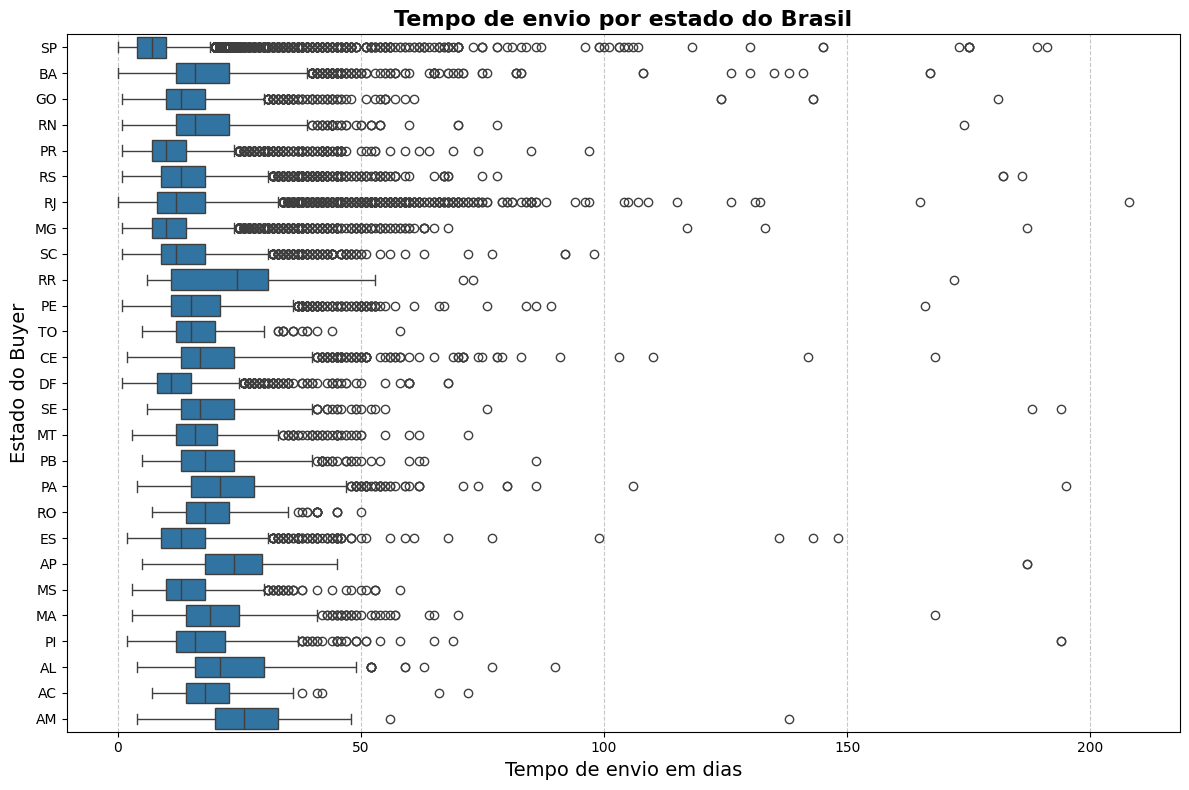

In [303]:
plt.figure(figsize=(12, 8))

df['review_score'] = df['review_score'].astype(int)

categ_bem_avaliadas = df[df["review_score"] > 3 ]


# Horizontal box plot for delivery time by simplified product category
sns.boxplot(x='delivery_time', y='customer_state', data=df)

# Overlay swarm plot to show individual points
#sns.swarmplot(x='delivery_time', y='simplified_category', data=df, color='k', alpha=0.6, size=3)

# Adding titles and labels
plt.title('Tempo de envio por estado do Brasil', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de envio em dias', fontsize=14)
plt.ylabel('Estado do Buyer', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

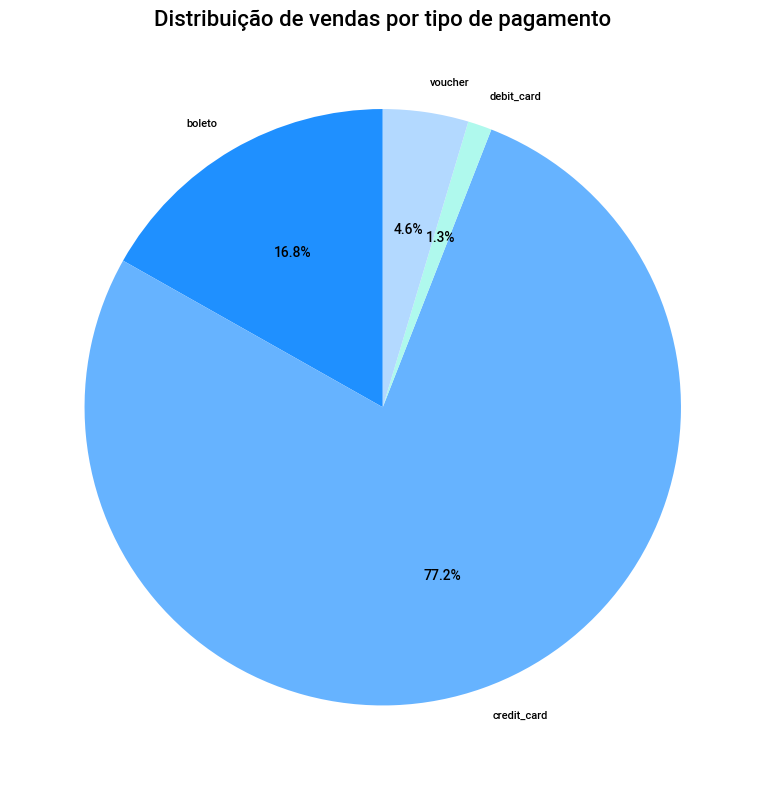

In [317]:

plt.figure(figsize=(8, 8))
cores = ['#1f90ff', '#66b3ff', '#aff9ed', '#b3d9ff', '#defcfe']

# Edistribuição de vendas por tipo de pagamento

sales_by_payment = df.groupby('payment_type')['price'].sum()
sales_by_payment.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors = cores)

# Adding title
plt.title('Distribuição de vendas por tipo de pagamento', fontsize=16, fontweight='bold')

# Hide the y-label for better aesthetics
plt.ylabel('')

plt.tight_layout()
plt.show()

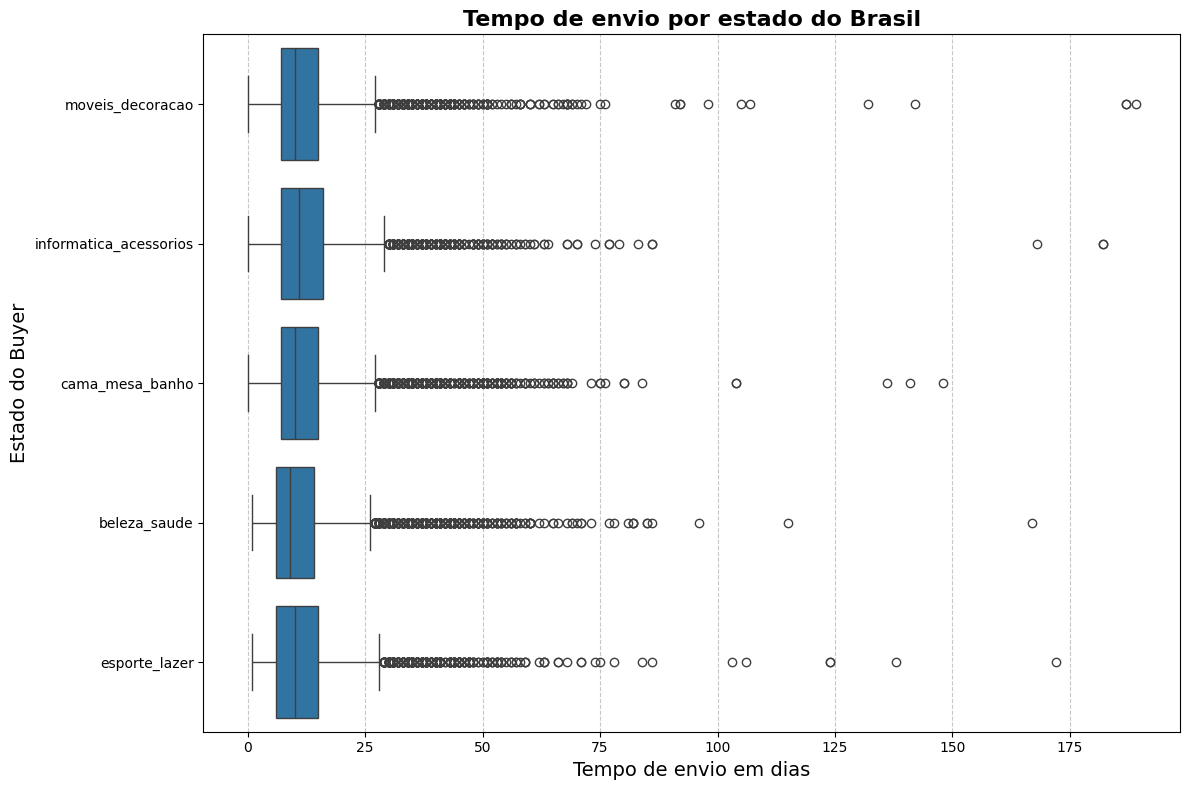

In [ ]:
plt.figure(figsize=(12, 8))

categ_bem_avaliadas = df[(df["product_category_name"] == 'cama_mesa_banho') | 
                         (df["product_category_name"] == 'beleza_saude') |
                         (df["product_category_name"] == 'esporte_lazer') | 
                         (df["product_category_name"] == 'moveis_decoracao') |
                         (df["product_category_name"] == 'informatica_acessorios')
                         ]


# Horizontal box plot for delivery time by simplified product category
sns.boxplot(x='delivery_time', y='product_category_name', data=categ_bem_avaliadas)

# Overlay swarm plot to show individual points
#sns.swarmplot(x='delivery_time', y='simplified_category', data=df, color='k', alpha=0.6, size=3)

# Adding titles and labels
plt.title('Tempo de envio por categoria (com mais pedidos)', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de envio em dias', fontsize=14)
plt.ylabel('Estado do Buyer', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

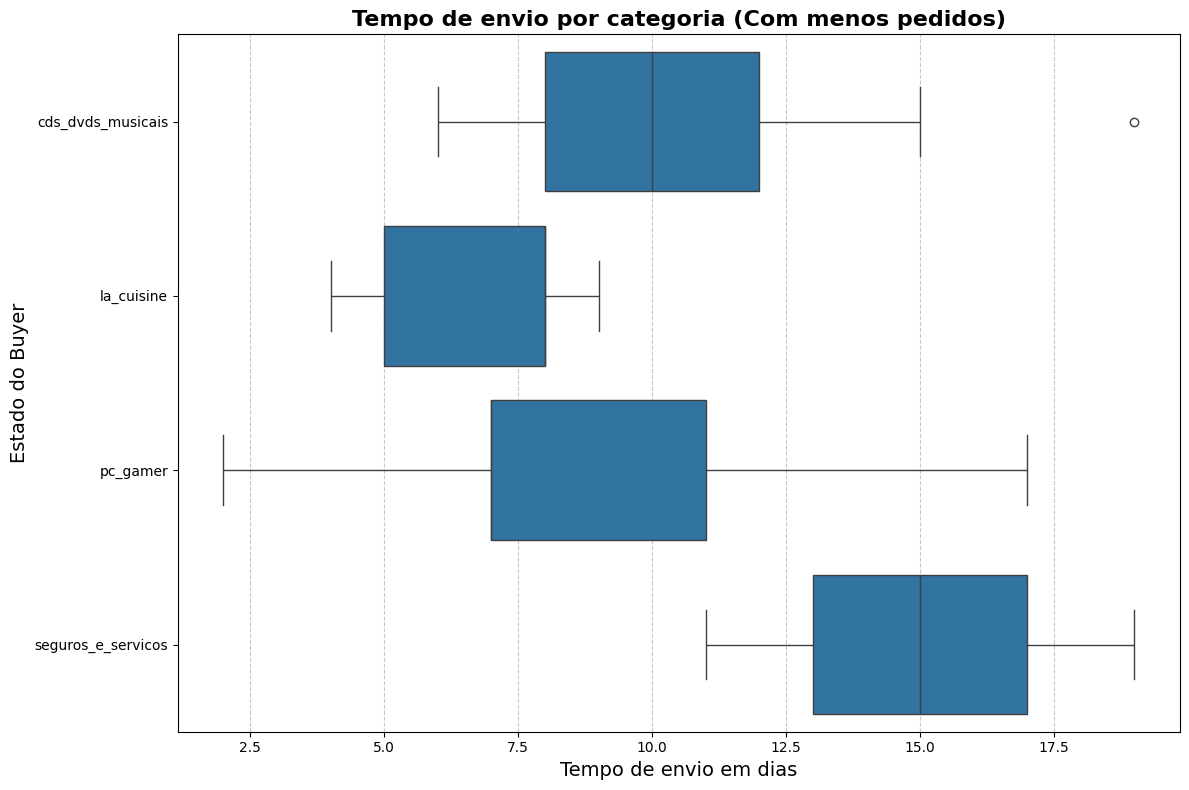

In [311]:
plt.figure(figsize=(12, 8))
categ_bem_avaliadas = df[(df["product_category_name"] == 'seguros_e_servicos') | 
                         (df["product_category_name"] == 'fashio_roua_infanto_juvenil') |
                         (df["product_category_name"] == 'pc_gamer') | 
                         (df["product_category_name"] == 'cds_dvds_musicais') |
                         (df["product_category_name"] == 'la_cuisine')
                         ]


# Horizontal box plot for delivery time by simplified product category
sns.boxplot(x='delivery_time', y='product_category_name', data=categ_bem_avaliadas)

# Overlay swarm plot to show individual points
#sns.swarmplot(x='delivery_time', y='simplified_category', data=df, color='k', alpha=0.6, size=3)

# Adding titles and labels
plt.title('Tempo de envio por categoria (Com menos pedidos)', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de envio em dias', fontsize=14)
plt.ylabel('Estado do Buyer', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [314]:
df.to_excel('dados.xlsx', index=False)

In [315]:
%pip install sweetviz
import sweetviz as sv

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   ----------------------------- ---------- 11.0/15.1 MB 57.2 MB/s eta 0:00:01
   ---------------------------------------- 15.1/15.1 MB 45.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [316]:
report = sv.analyze(df)

report.show_html('eda_report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
